In [1]:
# Importing the libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Peek into the data by creating pandas dataframe
star_df = pd.read_csv('data/cleaned_star_data.csv')
star_df.sample(10) # Random 10 samples from star_df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
128,2856,0.000896,0.0782,19.560,0,Red,M
161,11567,251000.000000,36.0000,-6.245,4,Blue,O
129,2731,0.000437,0.0856,18.090,0,Red,M
221,12749,332520.000000,76.0000,-7.020,4,Blue,O
163,5752,245000.000000,97.0000,-6.630,4,Blue,O
112,3615,200000.000000,1635.0000,-11.330,5,Red,M
223,23440,537430.000000,81.0000,-5.975,4,Blue,O
135,3243,0.002300,0.7300,14.750,1,Red,M
153,16390,1278.000000,5.6800,-3.320,3,Blue-White,B
31,30000,28840.000000,6.3000,-4.200,3,Blue-White,B


In [3]:
# Check general information about the dataframe
star_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


### Observations
**1)** Dataset consists of 240 rows, 6 feature and 1 target columns,
- *Absolute Temperature (in K)*    
- *Relative Luminosity (L/Lo)*
- *Relative Radius (R/Ro)*
- *Absolute Magnitude (Mv)*
- *Star Color*
- *Spectral Class*
- *Star Type (Target classes)*
    
Here,
- *Lo = 3.828 x 10^26 Watts (Avg Luminosity of Sun)*
- *Ro = 6.9551 x 10^8 m (Avg Radius of Sun)*
    
**2)** Two categorical features (object type) which will need some kind of encoding,
- *Star Color*
- *Spectral Class*

**3)** It consists of some different features of stars. Information on the star type is given below,       
- **0** → Brown Dwarf       
- **1** → Red Dwarf       
- **2** → White Dwarf      
- **3** → Main Sequence    
- **4** → Supergiants      
- **5** → Hypergiants      

In [4]:
# Create a directory to save the visualizations
folder_name = 'star_plots'                     # directory name
os.makedirs(folder_name, exist_ok=True)        # Create directory if not existing
base_dir = f'./{folder_name}/'                 # Store the path of this directory as base_dir to use it further
print(base_dir)

./star_plots/


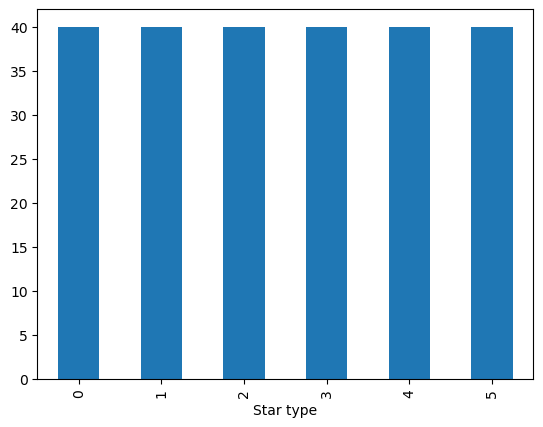

In [5]:
# Bar chart to visualize the count of stars with respective type
star_df['Star type'].value_counts().plot(kind='bar')
plt.show()

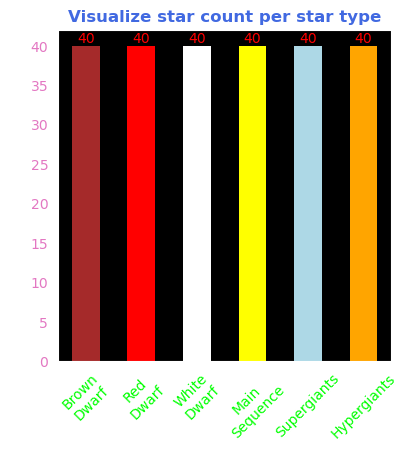

In [6]:
# Customize the plot
plt.figure(figsize=(4.3,4.3))
plt.style.use('dark_background')
ax = star_df['Star type'].value_counts().plot(kind='bar', color=['brown', 'red', 'white', 'yellow', 'lightblue', 'orange'])
ax.bar_label(ax.containers[0], color='red')
plt.title('Visualize star count per star type', color='royalblue', weight='bold')
plt.yticks(color='tab:pink')
plt.ylabel('# of Stars', color='white', fontsize=11)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5],
           labels=['Brown\nDwarf', 'Red\nDwarf', 'White\nDwarf', 'Main\nSequence', 'Supergiants', 'Hypergiants'],
           rotation=45, color='lime')

plt.savefig(base_dir+'barplot_star_count.png')
plt.show()

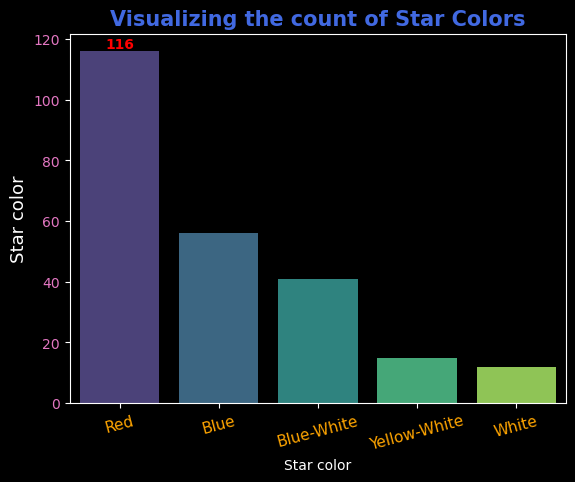

In [25]:
# Visualizing the Star color data
ax = sns.barplot(x=star_df['Star color'].value_counts().index,
            y=star_df['Star color'].value_counts(),
            palette='viridis', hue=star_df['Star color'].value_counts().index, legend=False)
ax.bar_label(ax.containers[0], color='red', weight='bold')

plt.title('Visualizing the count of Star Colors', color='royalblue', fontsize=15, weight='bold')
plt.xticks(rotation=15, color='orange', fontsize=11)
plt.ylabel('Star color',color='white', fontsize=13)
plt.yticks(color='tab:pink')
plt.savefig(base_dir+'star_colors_viz.png')
plt.show()

In [10]:
print(star_df['Star color'].value_counts())

Star color
Red             116
Blue             56
Blue-White       41
Yellow-White     15
White            12
Name: count, dtype: int64


In [26]:
# Get a gist of the data again by checking the top 5 rows of the data
star_df.head(5)

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


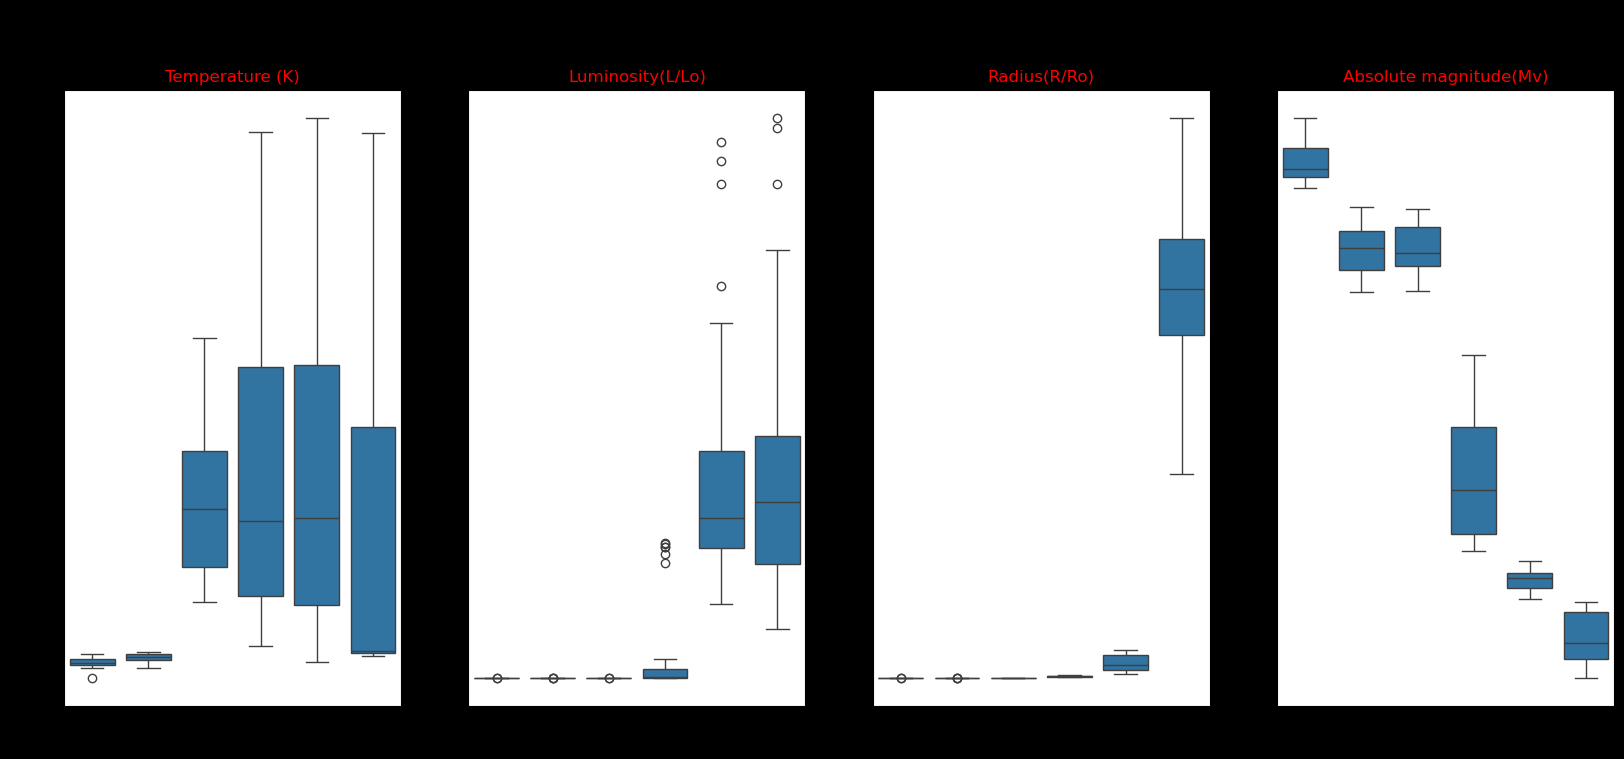

In [27]:
# Visualize Outliers in the Data
plt.figure(figsize=(20,8))
plt.style.use('default')
plt.suptitle('Visualizing the outliers in Numeric features of Star Type',
             color='black', weight='bold', fontsize=15)

# Using for loop to easily repeat some steps to create subplot
for i in range(4):
  plt.subplot(1, 4, i+1)
  sns.boxplot(x=star_df['Star type'], y=star_df.iloc[:, i])
  plt.title(star_df.columns[i], color='red')
  plt.ylabel('')

# Saving the figure
plt.savefig(base_dir+'boxplot_star_type.png')

**0** → Brown Dwarf      
**1** → Red Dwarf       
**2** → White Dwarf       
**3** → Main Sequence      
**4** → Supergiants      
**5** → Hypergiants